In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [4]:
df.shape

(8807, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [8]:

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

In [9]:
print(missing_df[missing_df['Missing Count'] > 0])

            Missing Count  Missing %
director             2634      29.91
country               831       9.44
cast                  825       9.37
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


In [10]:
print(f"Total duplicates: {df.duplicated().sum()}")

for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Total duplicates: 0
show_id: 8807 unique values
type: 2 unique values
title: 8807 unique values
director: 4528 unique values
cast: 7692 unique values
country: 748 unique values
date_added: 1767 unique values
release_year: 74 unique values
rating: 17 unique values
duration: 220 unique values
listed_in: 514 unique values
description: 8775 unique values


DATA CLEANING

In [11]:
df.drop_duplicates(inplace=True)
print(f"Duplicates removed. New shape: {df.shape}")

Duplicates removed. New shape: (8807, 12)


In [12]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('No Cast Info', inplace=True)
df['country'].fillna(df['country'].mode()[0], inplace=True)
df['date_added'].fillna(df['date_added'].mode()[0], inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df.dropna(subset=['duration'], inplace=True)

In [13]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.strftime('%B')

In [14]:
# Duration split
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract(r'([A-Za-z]+)')

In [15]:
df['type'] = df['type'].str.strip().str.title()
df['rating'] = df['rating'].str.strip()

In [16]:
print(f"\n Final shape: {df.shape}")
print(f"\nRemaining nulls:\n{df.isnull().sum()}")


 Final shape: (8804, 17)

Remaining nulls:
show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
year_added        0
month_added       0
month_name        0
duration_value    0
duration_unit     0
dtype: int64


In [17]:
sns.set_theme(style="darkgrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

NETFLIX_RED = '#E50914'
NETFLIX_DARK = '#221F1F'
COLORS = ['#E50914', '#F5A623', '#4A90D9', '#7ED321', '#9B59B6', '#1ABC9C', '#E67E22']


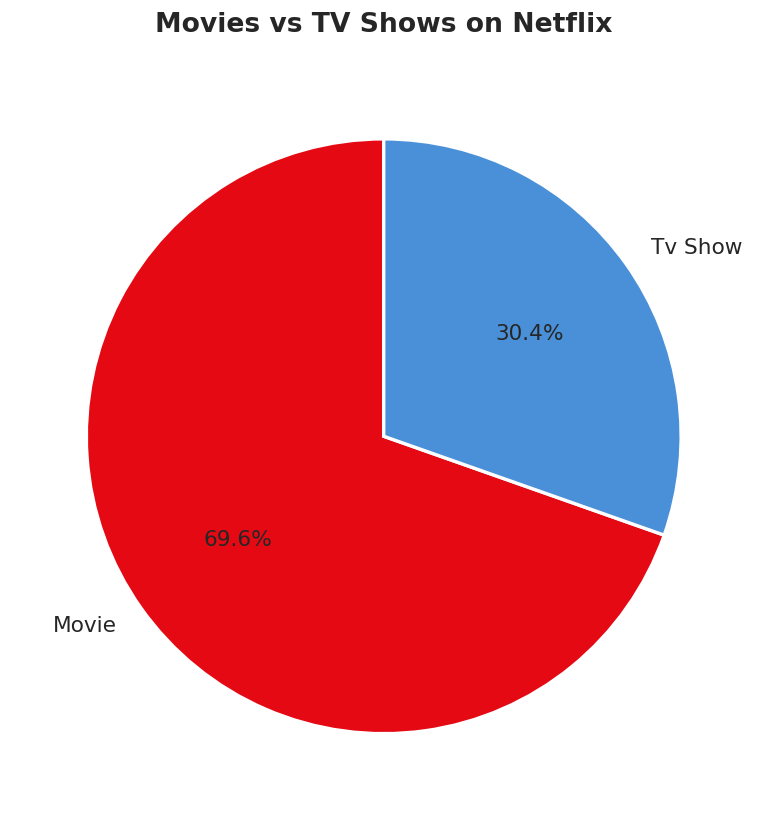

✅ Chart 1 done


In [18]:
fig, ax = plt.subplots(figsize=(7, 7))
type_counts = df['type'].value_counts()
ax.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
       colors=[NETFLIX_RED, '#4A90D9'], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2},
       textprops={'fontsize': 13})
ax.set_title('Movies vs TV Shows on Netflix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('chart1_movies_vs_shows.png', bbox_inches='tight')
plt.show()
print("✅ Chart 1 done")

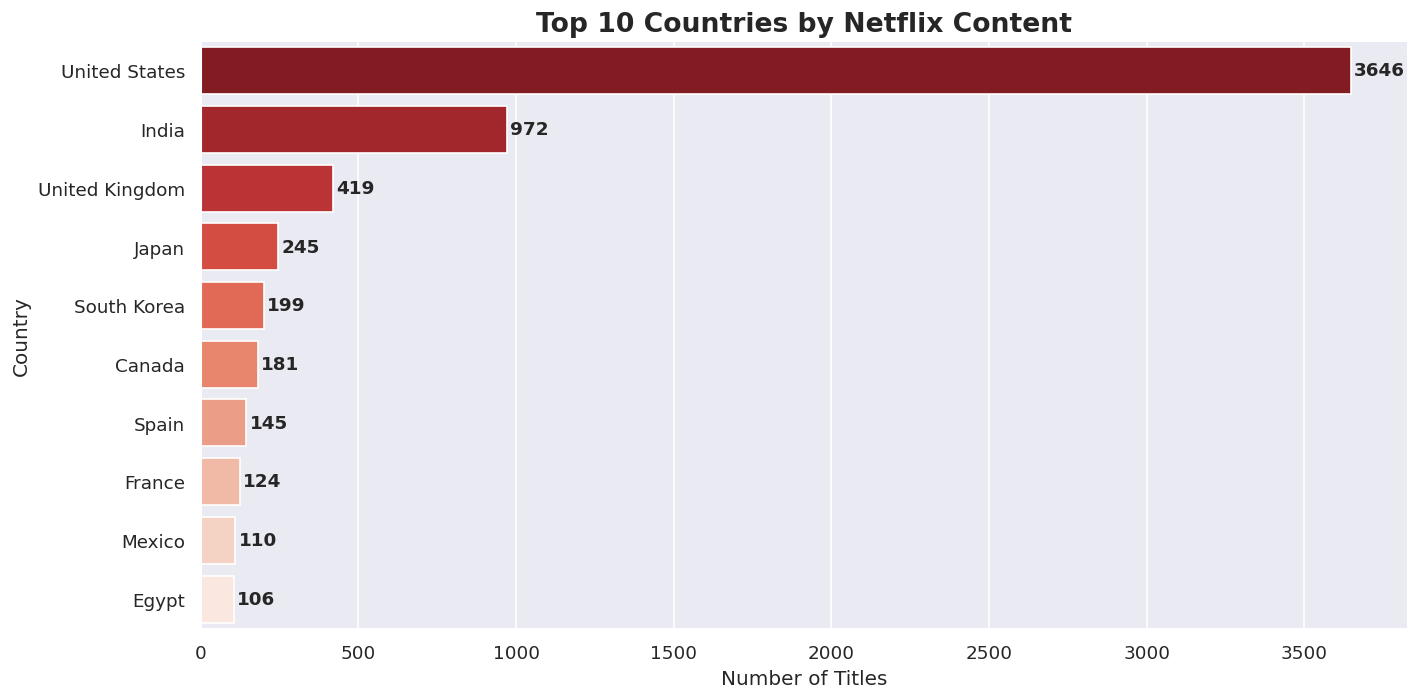

Chart 2 done


In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index,
            palette='Reds_r', ax=ax)
ax.set_title('Top 10 Countries by Netflix Content', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Titles', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
for i, v in enumerate(top_countries.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_top_countries.png', bbox_inches='tight')
plt.show()
print("Chart 2 done")

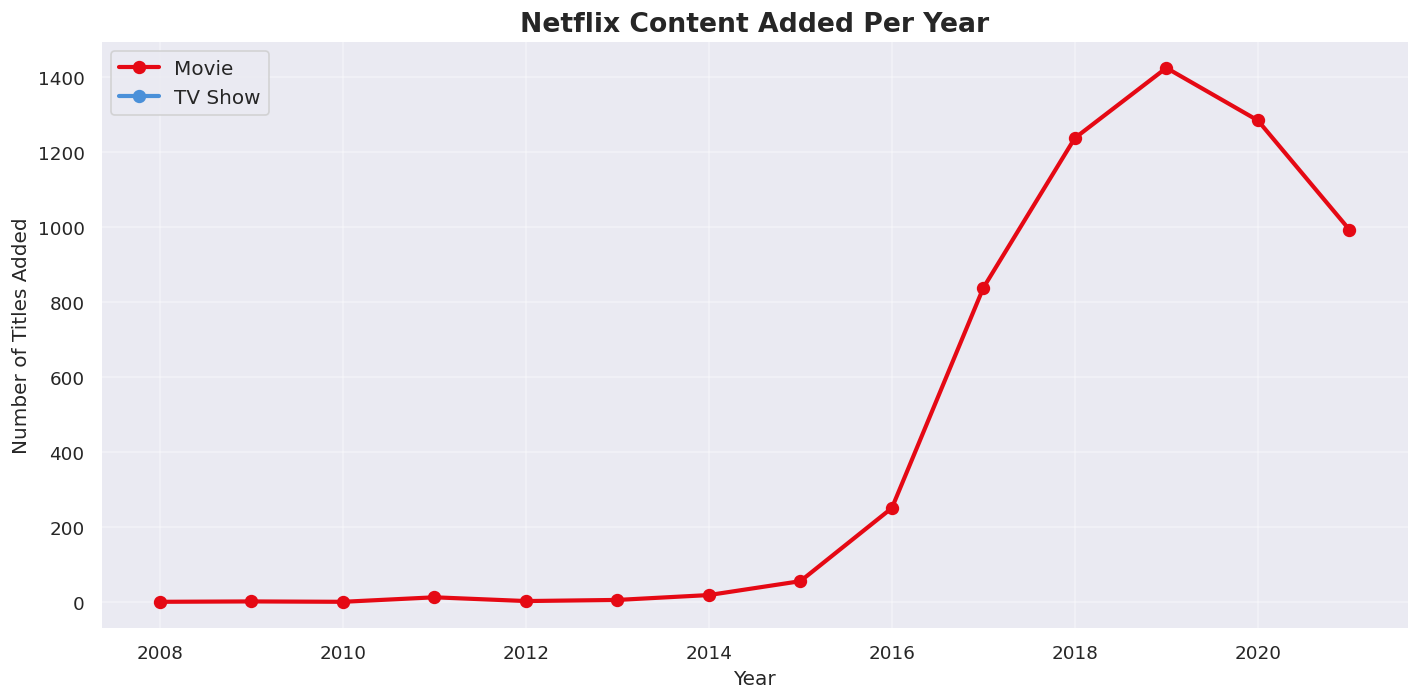

Chart 3 done


In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
yearly = df.groupby(['year_added', 'type']).size().reset_index(name='count')
for content_type, color in zip(['Movie', 'TV Show'], [NETFLIX_RED, '#4A90D9']):
    data = yearly[yearly['type'] == content_type]
    ax.plot(data['year_added'], data['count'], marker='o',
            label=content_type, color=color, linewidth=2.5, markersize=7)
ax.set_title('Netflix Content Added Per Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Titles Added', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('chart3_content_per_year.png', bbox_inches='tight')
plt.show()
print("Chart 3 done")

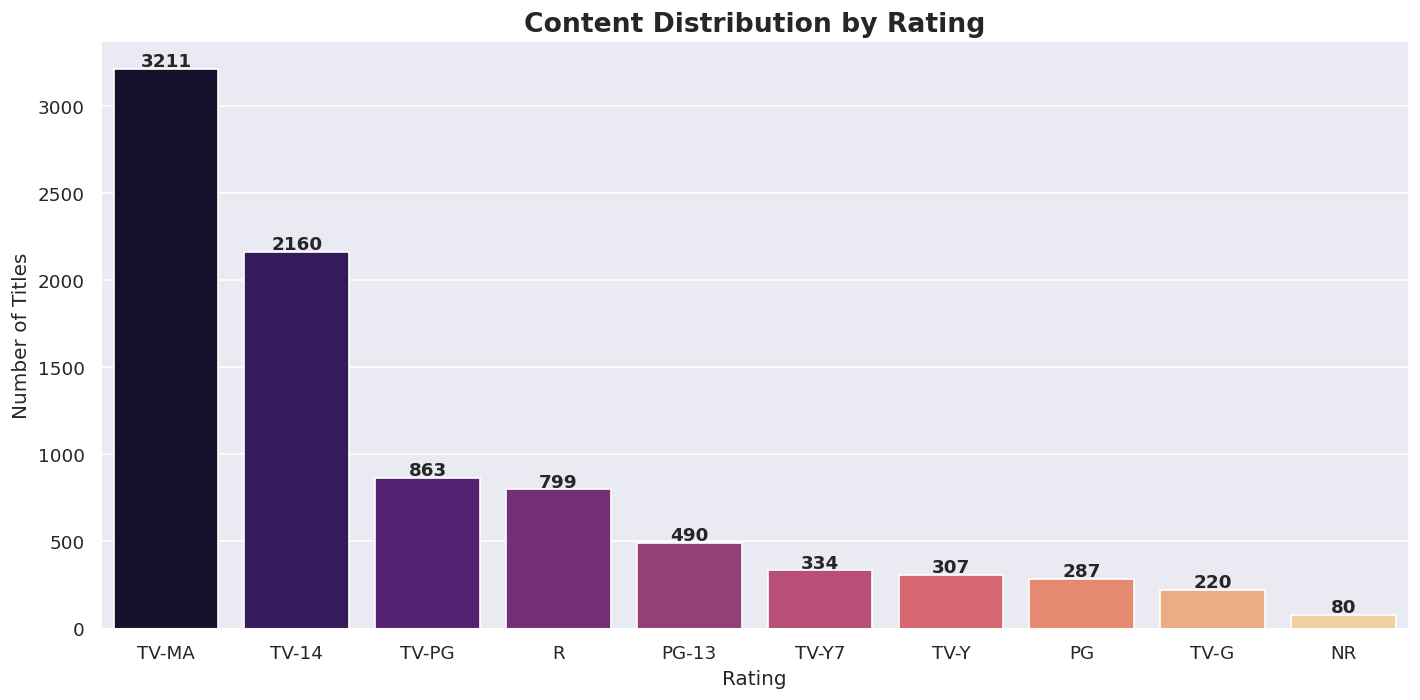

Chart 4 done


In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
rating_counts = df['rating'].value_counts().head(10)
sns.barplot(x=rating_counts.index, y=rating_counts.values,
            palette='magma', ax=ax)
ax.set_title('Content Distribution by Rating', fontsize=16, fontweight='bold')
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
for i, v in enumerate(rating_counts.values):
    ax.text(i, v + 15, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_ratings.png', bbox_inches='tight')
plt.show()
print("Chart 4 done")

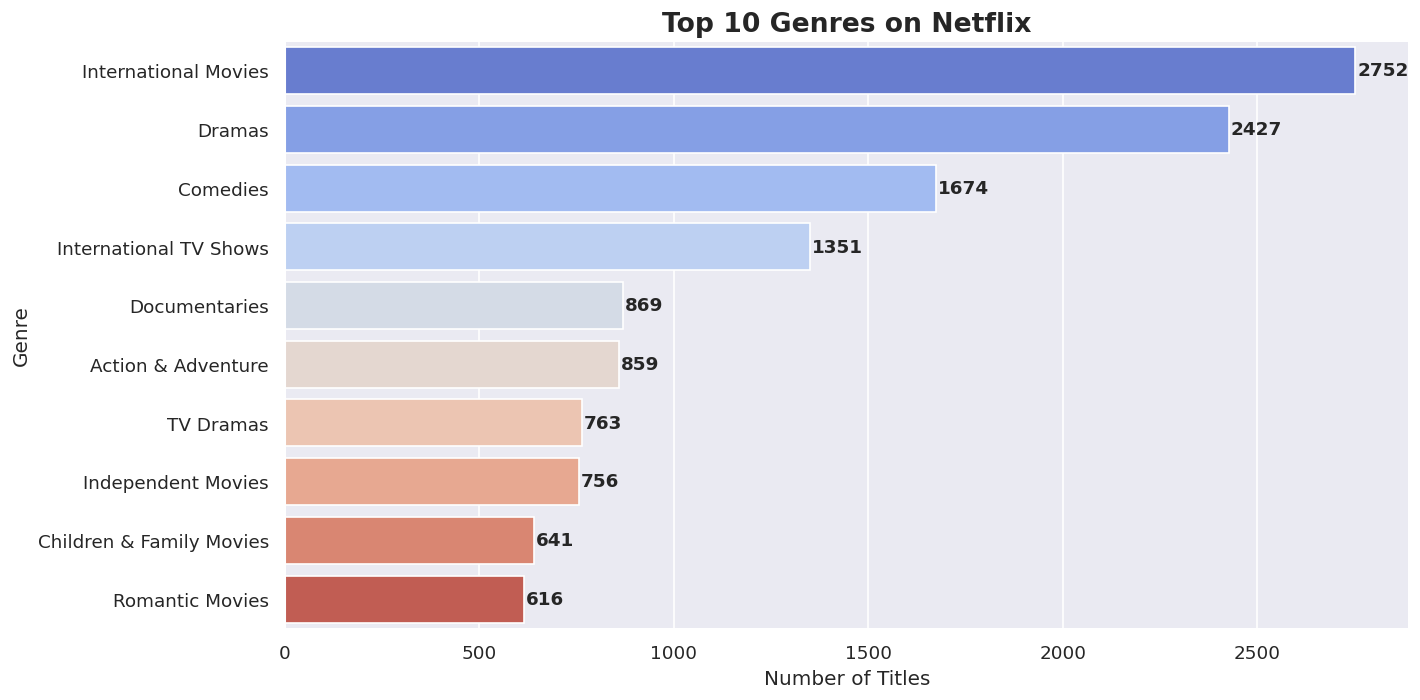

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index,
            palette='coolwarm', ax=ax)
ax.set_title('Top 10 Genres on Netflix', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Titles', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)
for i, v in enumerate(top_genres.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_top_genres.png', bbox_inches='tight')
plt.show()

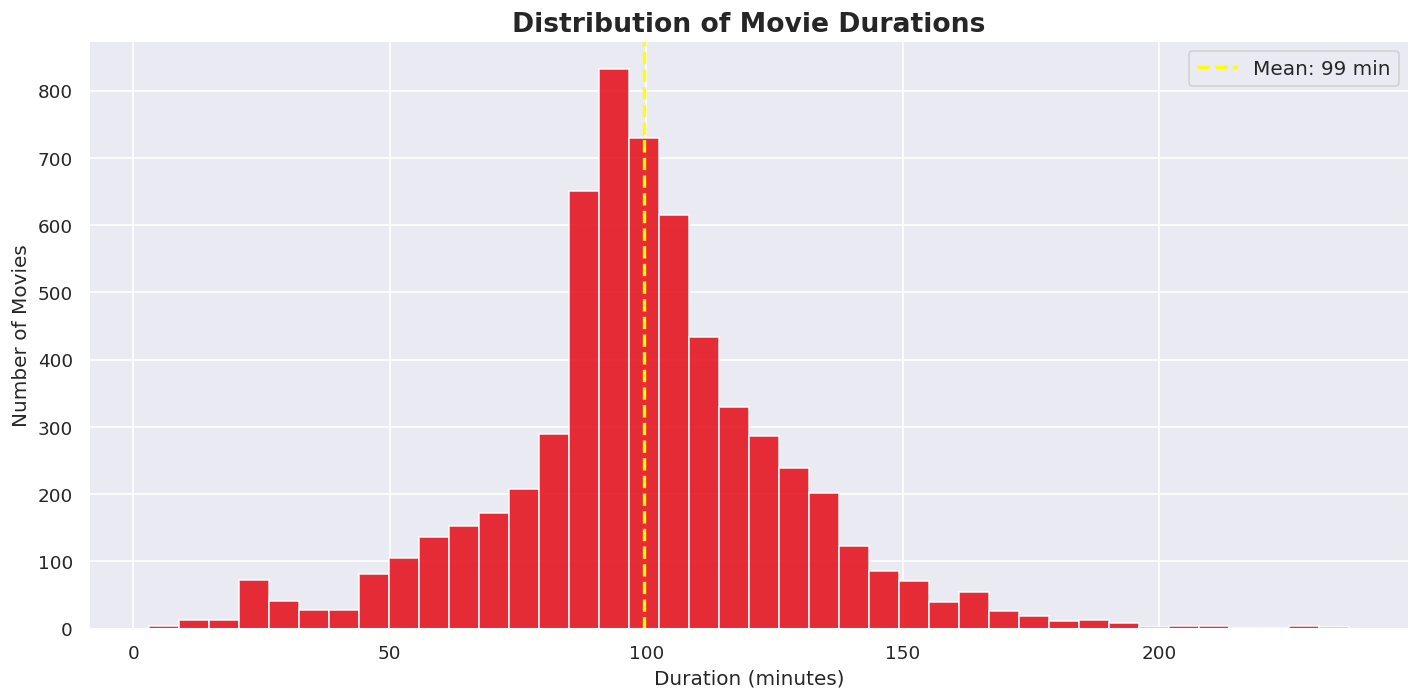

Chart 6 done


In [23]:
fig, ax = plt.subplots(figsize=(12, 6))
movies_only = df[(df['type'] == 'Movie') & (df['duration_value'] < 250)]
ax.hist(movies_only['duration_value'], bins=40,
        color=NETFLIX_RED, edgecolor='white', alpha=0.85)
ax.axvline(movies_only['duration_value'].mean(), color='yellow',
           linestyle='--', linewidth=2,
           label=f"Mean: {movies_only['duration_value'].mean():.0f} min")
ax.set_title('Distribution of Movie Durations', fontsize=16, fontweight='bold')
ax.set_xlabel('Duration (minutes)', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('chart6_movie_duration.png', bbox_inches='tight')
plt.show()
print("Chart 6 done")

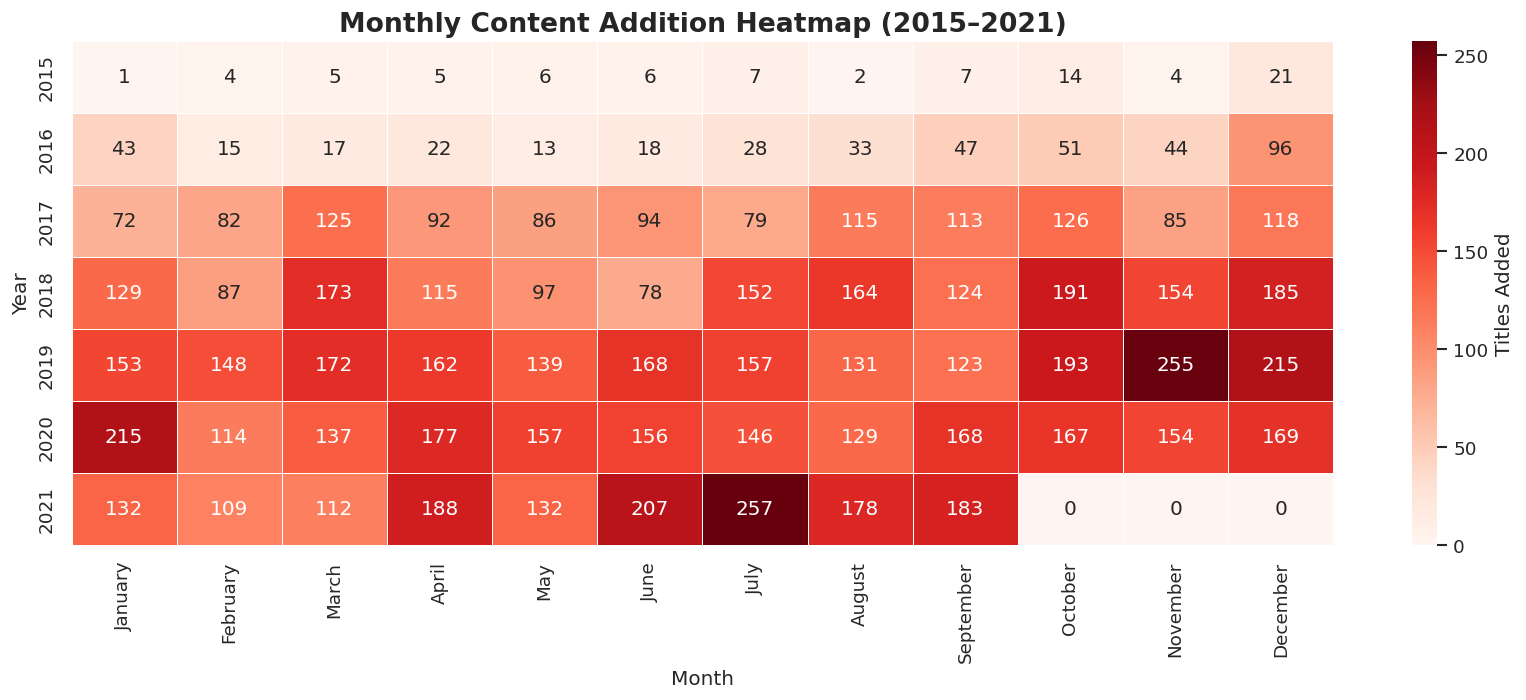

Chart 7 done

 All 7 charts completed!


In [24]:
fig, ax = plt.subplots(figsize=(14, 6))
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
heatmap_data = df.groupby(['year_added', 'month_name']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(columns=month_order, fill_value=0)
heatmap_data = heatmap_data[heatmap_data.index >= 2015]
sns.heatmap(heatmap_data, cmap='Reds', annot=True, fmt='d',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Titles Added'})
ax.set_title('Monthly Content Addition Heatmap (2015–2021)', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
plt.tight_layout()
plt.savefig('chart7_monthly_heatmap.png', bbox_inches='tight')
plt.show()
print("Chart 7 done")

print("\n All 7 charts completed!")

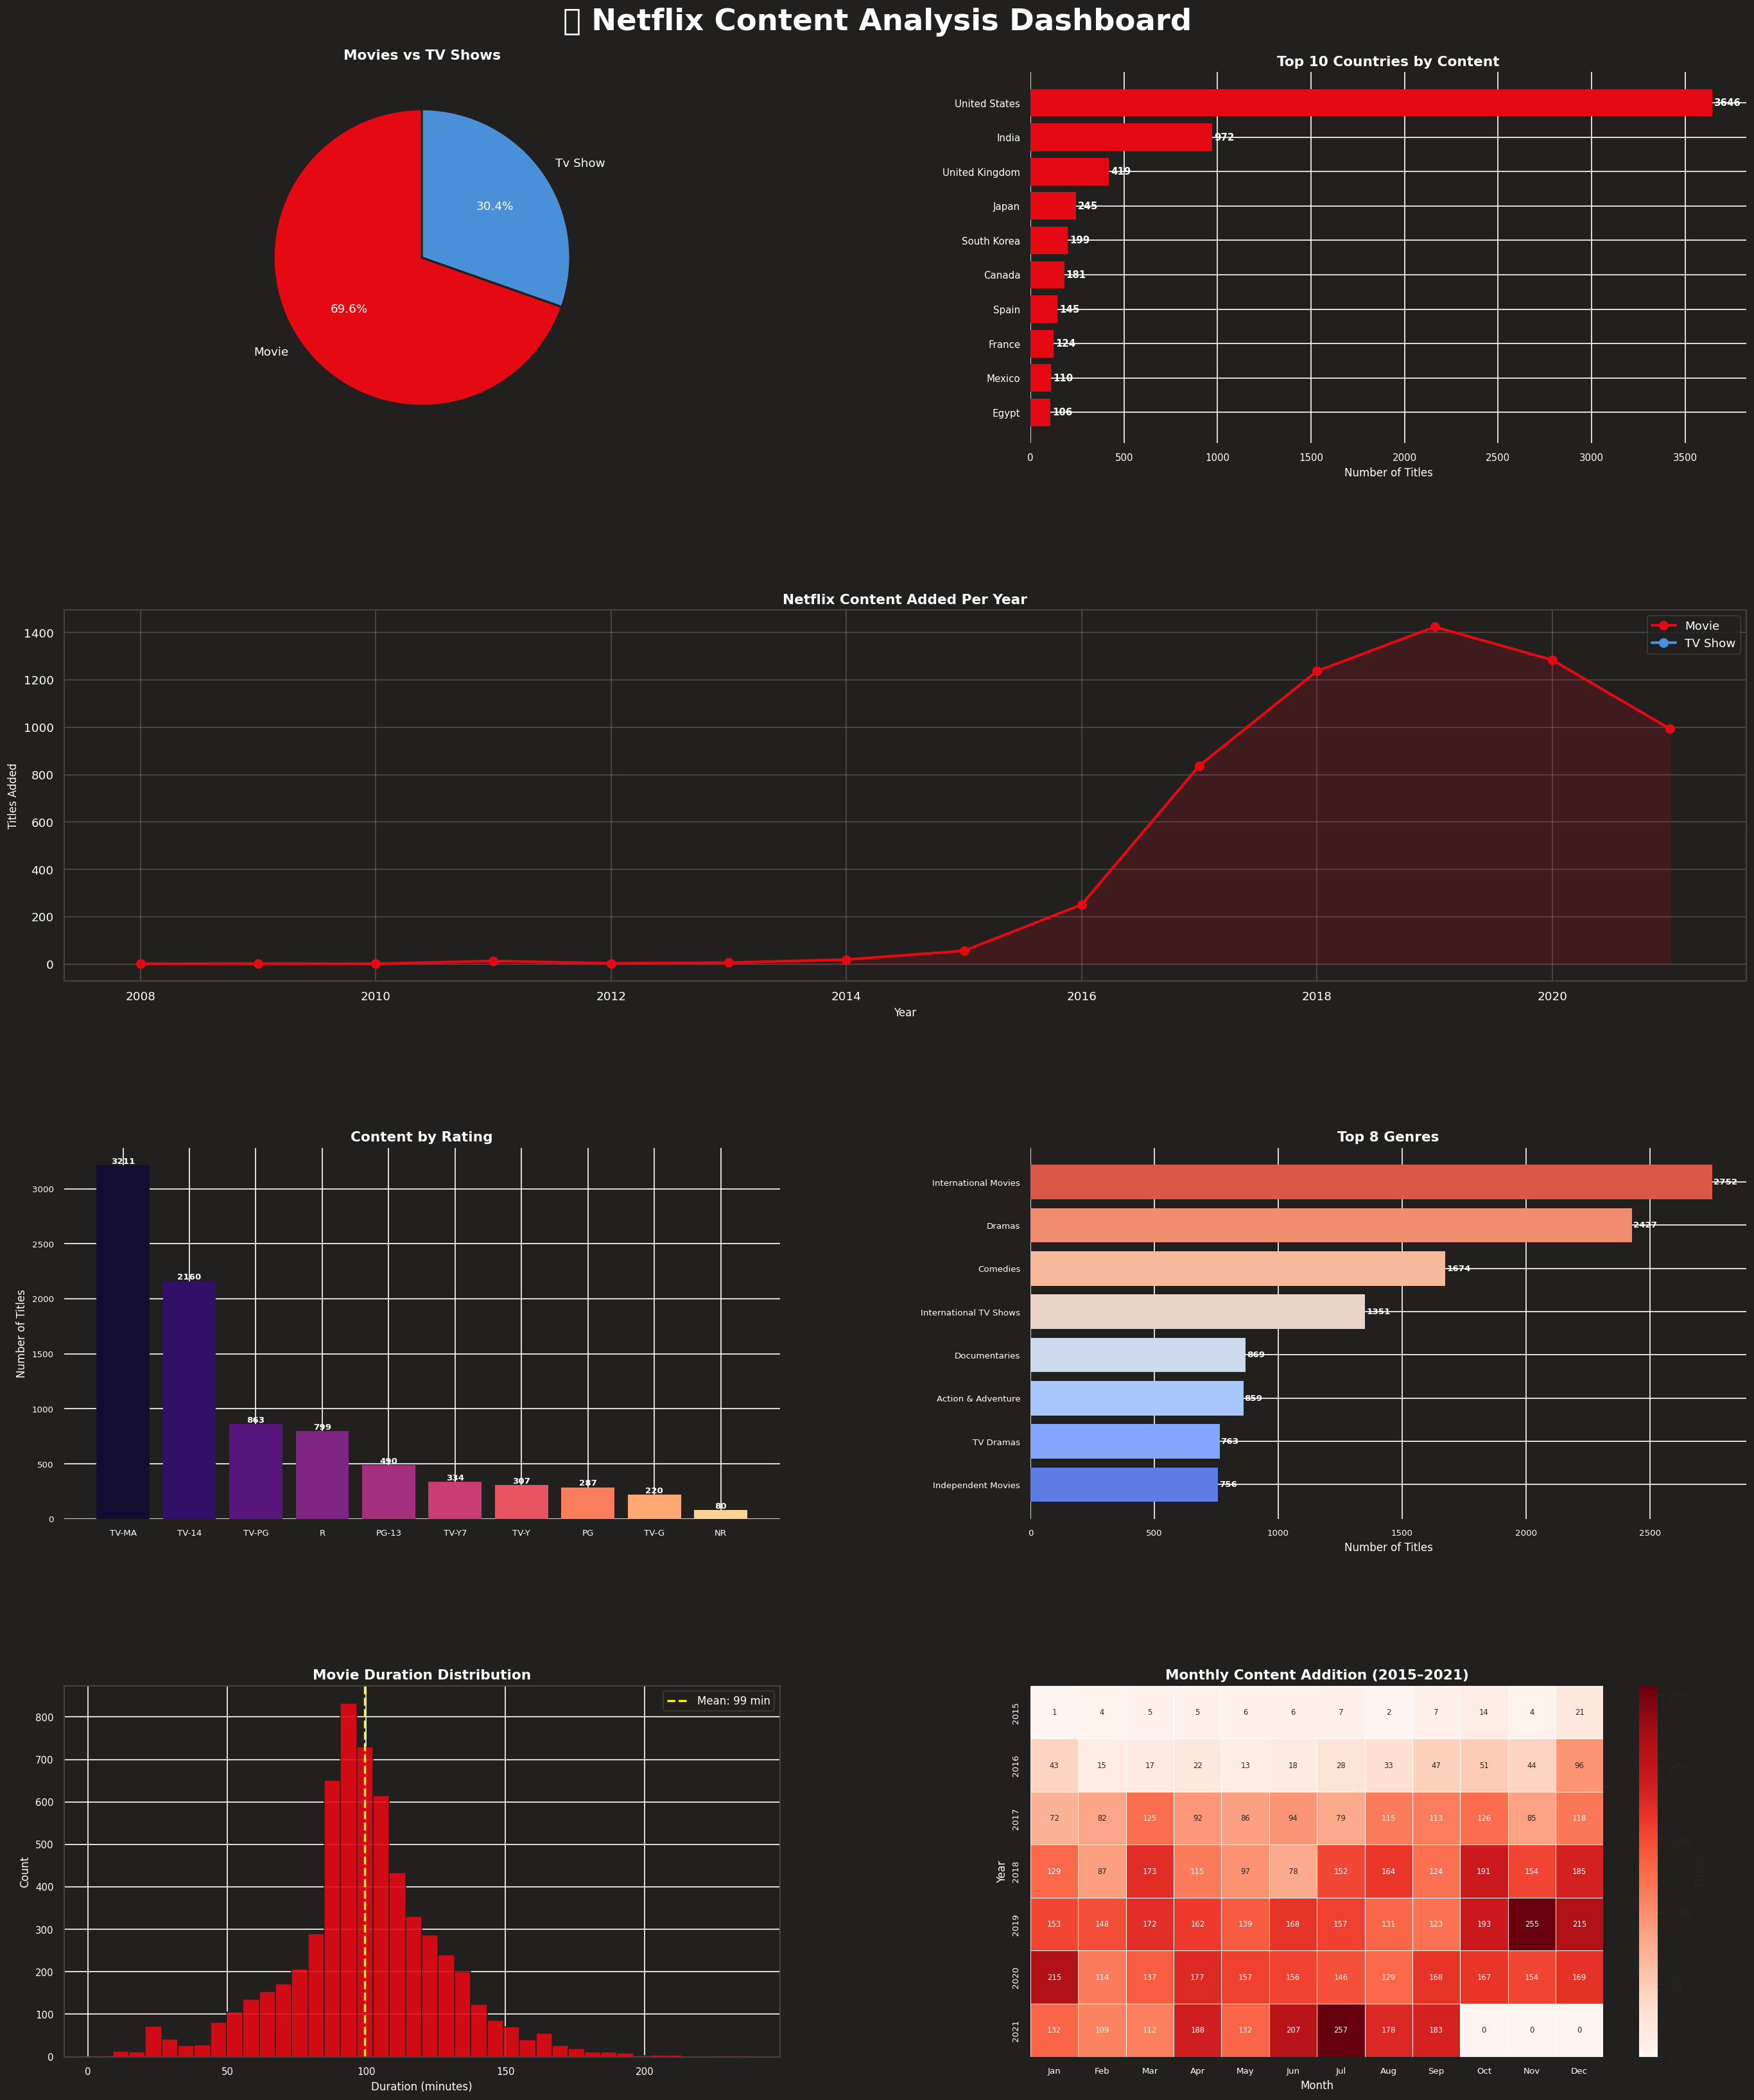

🎉 Dashboard saved as netflix_dashboard.png


In [25]:
# ============================================
# NETFLIX DATA DASHBOARD — FINAL SUBMISSION
# ============================================

fig = plt.figure(figsize=(24, 28), facecolor=NETFLIX_DARK)
fig.suptitle('🎬 Netflix Content Analysis Dashboard',
             fontsize=28, fontweight='bold',
             color='white', y=0.98)

# Grid layout — 4 rows, 2 cols (with one spanning full width)
gs = fig.add_gridspec(4, 2, hspace=0.45, wspace=0.35,
                      top=0.95, bottom=0.03, left=0.06, right=0.97)

# ── CHART 1 — Pie (top left) ──────────────────
ax1 = fig.add_subplot(gs[0, 0])
type_counts = df['type'].value_counts()
ax1.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=[NETFLIX_RED, '#4A90D9'], startangle=90,
        wedgeprops={'edgecolor': NETFLIX_DARK, 'linewidth': 2},
        textprops={'fontsize': 11, 'color': 'white'})
ax1.set_title('Movies vs TV Shows', fontsize=13,
              fontweight='bold', color='white', pad=12)
ax1.set_facecolor(NETFLIX_DARK)

# ── CHART 2 — Top Countries (top right) ───────
ax2 = fig.add_subplot(gs[0, 1])
top_countries = df['country'].value_counts().head(10)
bars = ax2.barh(top_countries.index[::-1], top_countries.values[::-1],
                color=NETFLIX_RED, edgecolor='none')
for bar, val in zip(bars, top_countries.values[::-1]):
    ax2.text(val + 10, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9, color='white', fontweight='bold')
ax2.set_title('Top 10 Countries by Content', fontsize=13,
              fontweight='bold', color='white')
ax2.set_facecolor(NETFLIX_DARK)
ax2.tick_params(colors='white', labelsize=9)
ax2.spines[:].set_visible(False)
ax2.set_xlabel('Number of Titles', color='white', fontsize=10)

# ── CHART 3 — Content per Year (full width) ───
ax3 = fig.add_subplot(gs[1, :])
yearly = df.groupby(['year_added', 'type']).size().reset_index(name='count')
for content_type, color in zip(['Movie', 'TV Show'], [NETFLIX_RED, '#4A90D9']):
    data = yearly[yearly['type'] == content_type]
    ax3.plot(data['year_added'], data['count'], marker='o',
             label=content_type, color=color, linewidth=2.5, markersize=8)
    ax3.fill_between(data['year_added'], data['count'], alpha=0.15, color=color)
ax3.set_title('Netflix Content Added Per Year', fontsize=13,
              fontweight='bold', color='white')
ax3.set_facecolor(NETFLIX_DARK)
ax3.tick_params(colors='white')
ax3.spines[:].set_color('#444')
ax3.legend(fontsize=11, facecolor=NETFLIX_DARK,
           labelcolor='white', edgecolor='#444')
ax3.set_xlabel('Year', color='white', fontsize=10)
ax3.set_ylabel('Titles Added', color='white', fontsize=10)
ax3.grid(True, alpha=0.2, color='white')

# ── CHART 4 — Ratings (mid left) ──────────────
ax4 = fig.add_subplot(gs[2, 0])
rating_counts = df['rating'].value_counts().head(10)
bars4 = ax4.bar(rating_counts.index, rating_counts.values,
                color=sns.color_palette('magma', len(rating_counts)),
                edgecolor='none')
for bar, val in zip(bars4, rating_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 15,
             str(val), ha='center', fontsize=8,
             color='white', fontweight='bold')
ax4.set_title('Content by Rating', fontsize=13,
              fontweight='bold', color='white')
ax4.set_facecolor(NETFLIX_DARK)
ax4.tick_params(colors='white', labelsize=8)
ax4.spines[:].set_visible(False)
ax4.set_ylabel('Number of Titles', color='white', fontsize=10)

# ── CHART 5 — Top Genres (mid right) ──────────
ax5 = fig.add_subplot(gs[2, 1])
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(8)
bars5 = ax5.barh(top_genres.index[::-1], top_genres.values[::-1],
                 color=sns.color_palette('coolwarm', len(top_genres)),
                 edgecolor='none')
for bar, val in zip(bars5, top_genres.values[::-1]):
    ax5.text(val + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=8,
             color='white', fontweight='bold')
ax5.set_title('Top 8 Genres', fontsize=13,
              fontweight='bold', color='white')
ax5.set_facecolor(NETFLIX_DARK)
ax5.tick_params(colors='white', labelsize=8)
ax5.spines[:].set_visible(False)
ax5.set_xlabel('Number of Titles', color='white', fontsize=10)

# ── CHART 6 — Movie Duration (bottom left) ────
ax6 = fig.add_subplot(gs[3, 0])
movies_only = df[(df['type'] == 'Movie') & (df['duration_value'] < 250)]
ax6.hist(movies_only['duration_value'], bins=40,
         color=NETFLIX_RED, edgecolor=NETFLIX_DARK, alpha=0.9)
ax6.axvline(movies_only['duration_value'].mean(),
            color='yellow', linestyle='--', linewidth=2,
            label=f"Mean: {movies_only['duration_value'].mean():.0f} min")
ax6.set_title('Movie Duration Distribution', fontsize=13,
              fontweight='bold', color='white')
ax6.set_facecolor(NETFLIX_DARK)
ax6.tick_params(colors='white', labelsize=9)
ax6.spines[:].set_color('#444')
ax6.legend(fontsize=10, facecolor=NETFLIX_DARK,
           labelcolor='white', edgecolor='#444')
ax6.set_xlabel('Duration (minutes)', color='white', fontsize=10)
ax6.set_ylabel('Count', color='white', fontsize=10)

# ── CHART 7 — Heatmap (bottom right) ──────────
ax7 = fig.add_subplot(gs[3, 1])
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
df['month_short'] = df['date_added'].dt.strftime('%b')
heatmap_data = df.groupby(['year_added','month_short']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(columns=month_order, fill_value=0)
heatmap_data = heatmap_data[heatmap_data.index >= 2015]
sns.heatmap(heatmap_data, cmap='Reds', annot=True, fmt='d',
            linewidths=0.5, ax=ax7, annot_kws={'size': 7},
            cbar_kws={'label': 'Titles'})
ax7.set_title('Monthly Content Addition (2015–2021)',
              fontsize=13, fontweight='bold', color='white')
ax7.set_facecolor(NETFLIX_DARK)
ax7.tick_params(colors='white', labelsize=8)
ax7.set_xlabel('Month', color='white', fontsize=10)
ax7.set_ylabel('Year', color='white', fontsize=10)
ax7.yaxis.label.set_color('white')
ax7.xaxis.label.set_color('white')

# ── Save & Show ───────────────────────────────
plt.savefig('netflix_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor=NETFLIX_DARK)
plt.show()
print("Dashboard saved as netflix_dashboard.png")